In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import random
import seaborn as sns
sns.set_theme()

In [13]:
data = loadmat('cluster_dataset.mat')

In [14]:
X = data['data']
x1 = np.array([i[0] for i in X])
x2 = np.array([i[1] for i in X])

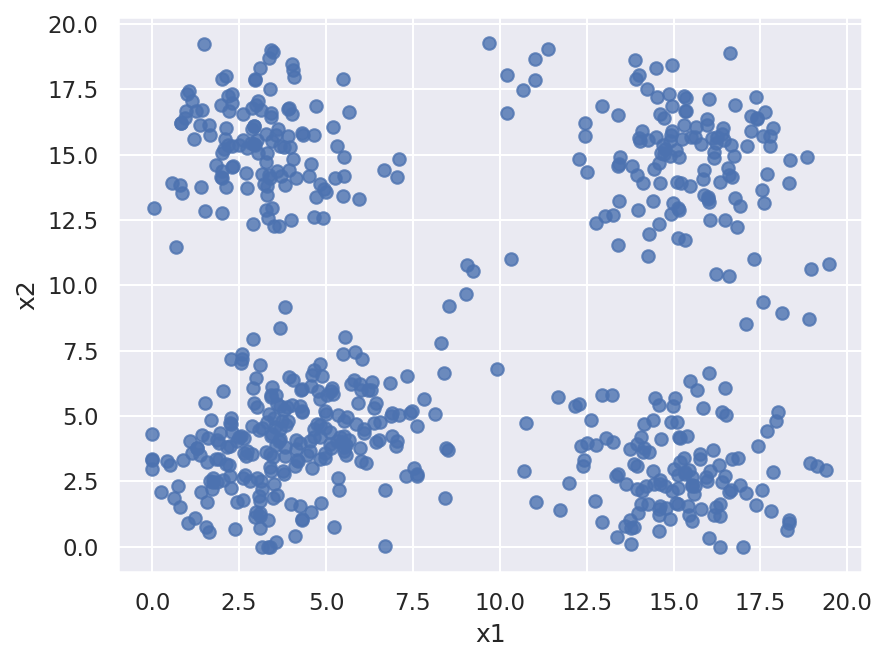

In [15]:
plt.figure(dpi=150)
plt.scatter(x1,x2,color='b',alpha=0.8)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [16]:
#预设聚类簇数k：请观察数据集散点图，预计聚类簇数k
k = 4

In [17]:
#随机选择数据集中k个点作为初始聚类中心
def init_centers(X,k):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int)
    输出：centers：初始化的中心集（建议：元素为ndarray的list)
    可能使用的函数：random.randint
    注意：需保证随机取的样本不重复
    """
    centers=[]
    n_samples=X.shapes[0]
    indices=[]
    while len(indices)<k:
        a=random.randint(0,n_samples-1)
        if a not in indices:#检查是否重复
            indices.append(a)
            centers.append(indices(X[a]))
    return centers

In [18]:
#向量欧氏距离计算，用于计算每个样本和中心的距离，可用于簇分配和代价函数计算
def distance(v1, v2):
    """
    输入：v1:样本(ndarray), v2:当前对应的中心(ndarray)
    输出：distance:欧氏距离(float/ndarray)
    """
    distance = np.linalg.norm(v1 - v2) 
    return distance

In [19]:
#将样本分配到距离最近的中心所在的簇
def cluster_assignment(X, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心集（建议：元素为ndarray的list)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list)
    可能使用的函数：np.argmin
    注意：list和array在某些计算时的转换
    """
    assignment = {i:[] for i in range(len(centers))}
    for point in X:
        distance = []
        for center in centers:
            dist = distance(point,center)
            distance.append(dist)
        cluster_id = np.argmin(distances)
        assignments[cluster_id].append(point)
    return assignment

In [20]:
#代价函数：所有数据点到当前对应中心的欧氏距离之和的平均值
def cost_function(assignment, centers):
    """
    输入：X:数据集(ndarray), centers：当前中心（建议：元素为ndarray的list)
    输出：cost:代价函数值（float/ndarray）
    可能使用的函数：np.argmin
    注意：list和array在使用np函数计算时的转换
    """
    total_distance=0
    n_samples=0
    for cluster_id,points in assignment.items():
        center=centers[cluster_id]
        for point in points:
            dist = distance(point,center)
            total_distance+=dist
            n_samples+=1
    cost = total_distance/n_samples
    return cost

In [21]:
#更新中心,满足停机条件（聚类中心不再改变）时结束更新
def center_update(assignment, centers):
    """
    输入：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), centers：当前中心（建议：元素为ndarray的list)
    输出：new_centers:更新的中心集（建议：元素为ndarray的list), stop：停机条件标识（不停机：0/停机：1）
    可能使用的函数：np.mean
    注意：list和array在使用np函数计算时的转换
    """
    
    return new_centers, stop

In [22]:
#聚类可视化
def plot_clustering(assignment, centers, epoch):
    color = ['r', 'b', 'c', 'g', 'k', 'w', 'y', 'm']
    plt.figure(dpi=150)
    for k in range(len(centers)):
        cluster = np.array(assignment[k])
        if len(cluster) == 0:
            continue
        x1 = cluster[:,0]
        x2 = cluster[:,1]
        plt.scatter(x1, x2, c=color[k])
        plt.xlabel('x1')
        plt.ylabel('x2')
    for k in range(len(centers)):
        x1 = centers[k][0]
        x2 = centers[k][1]
        plt.scatter(x1, x2, c='k', marker = '*')
        plt.xlabel('x1')
        plt.ylabel('x2')
    plt.title('epoch'+ str(epoch))
    plt.show()

In [26]:
#kmeans及可视化
def kmeans(X, k, max_epoch, plot=True):
    """
    输入：X:数据集(ndarray), k：预设的聚类簇数(int), max_epoch：最大训练轮数(int), plot:是否可视化（True/False)
    输出：assignment(建议：字典：key为簇标号、value为元素是ndarray的list), cost:最终的代价函数值，用于k-cost曲线的绘制（float/ndarray）
    """
    
    idx = np.random.choice(len(X), k, replace=False)
    centers = X[idx]
    
    for epoch in range(max_epoch):
        assignment = {i: [] for i in range(k)}
        for point in X:
            dist = np.linalg.norm(centers - point, axis=1)
            cluster_id = np.argmin(dist)
            assignment[cluster_id].append(point)
        
        
        new_centers = []
        for i in range(k):
            if len(assignment[i]) > 0:
                new_centers.append(np.mean(assignment[i], axis=0))
            else:
                new_centers.append(centers[i])
        new_centers = np.array(new_centers)
        
        
        if plot:
            plot_clustering(assignment, centers, epoch)
        
        
        if np.all(centers == new_centers):
            break
        
        centers = new_centers
    total_dist = 0
    n = 0
    for i in range(k):
        for point in assignment[i]:
            total_dist += np.linalg.norm(point - centers[i])
            n += 1
    cost = total_dist / n
    
    return assignment, cost
    return assignment, cost

In [27]:
max_epoch = 200 

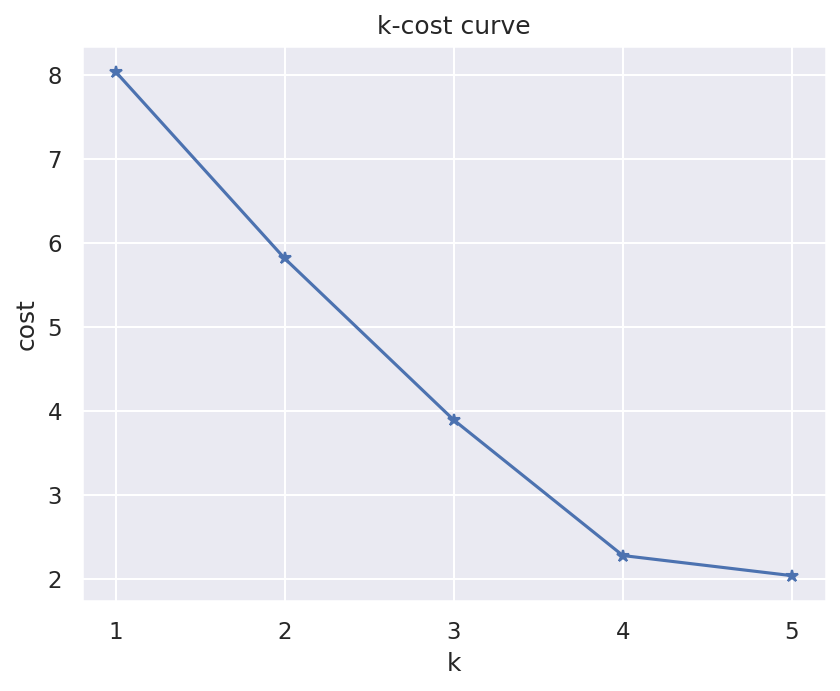

In [29]:
#绘制簇数-代价函数曲线：根据曲线，观察最合适的簇数k的选择
plt.figure(dpi=150)
Cost = []
max_k = 6
for k in range(1, max_k):
    _, cost = kmeans(X, k, max_epoch,False)
    Cost.append(cost)

plt.plot(range(1,max_k), Cost, c='b', marker = '*')
plt.xticks(range(1,max_k))
plt.xlabel('k')
plt.ylabel('cost')
plt.title('k-cost curve')
plt.show()

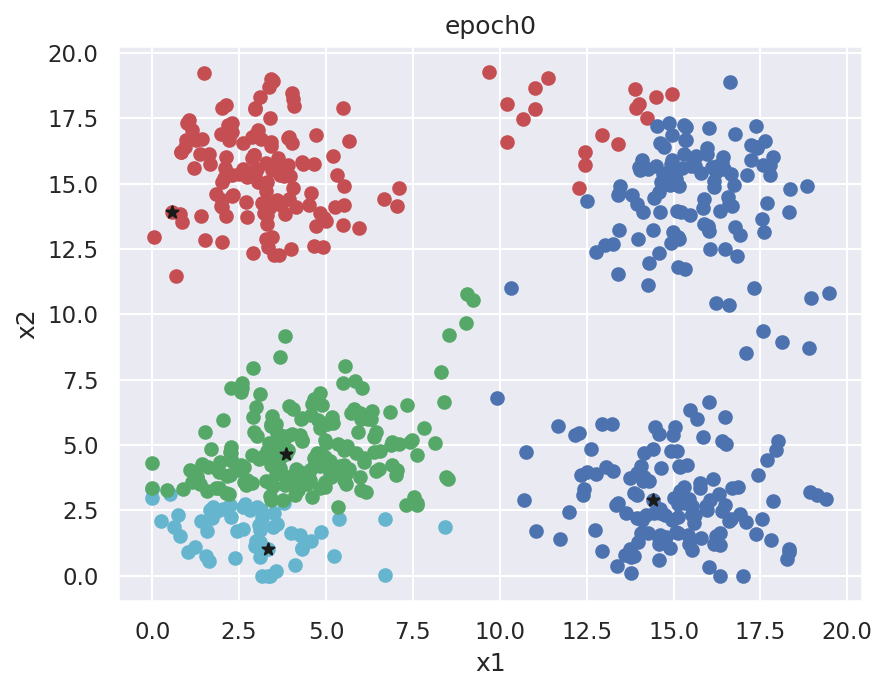

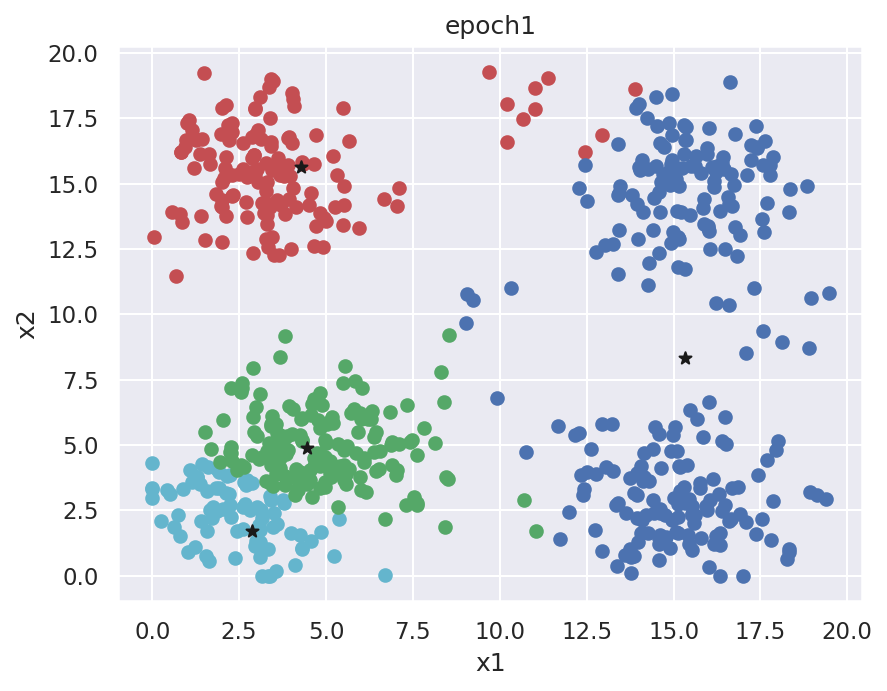

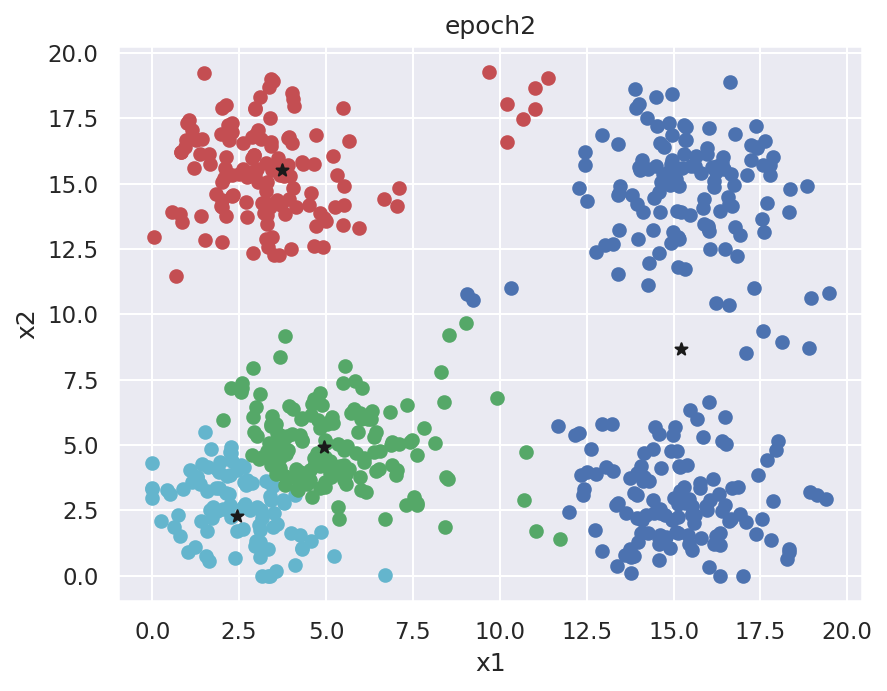

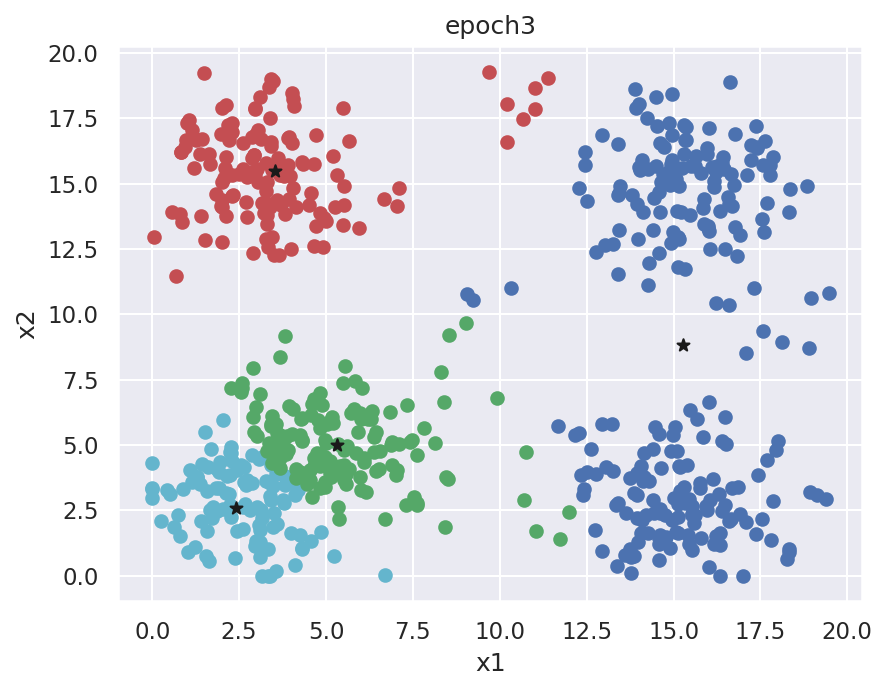

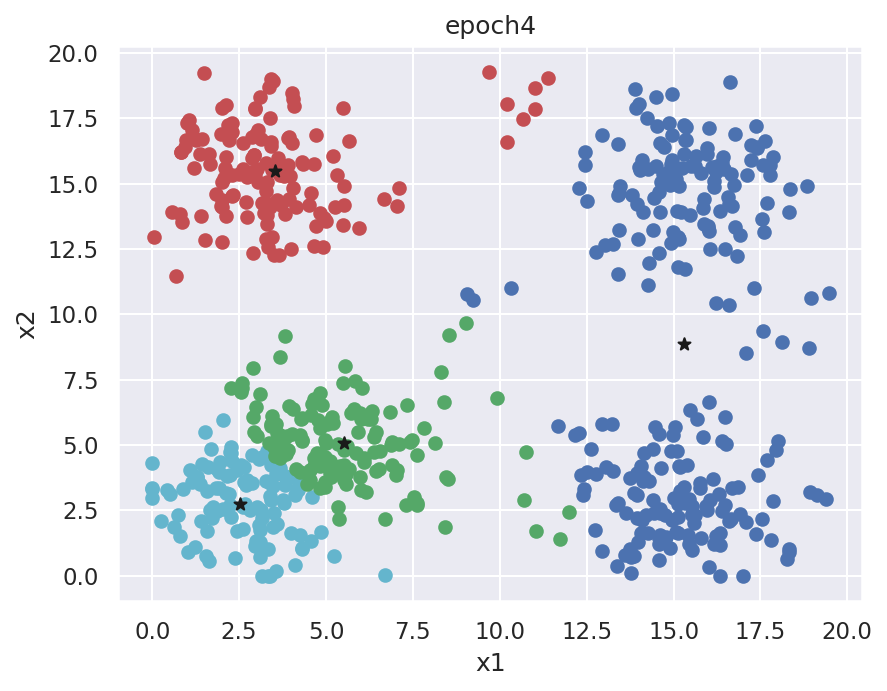

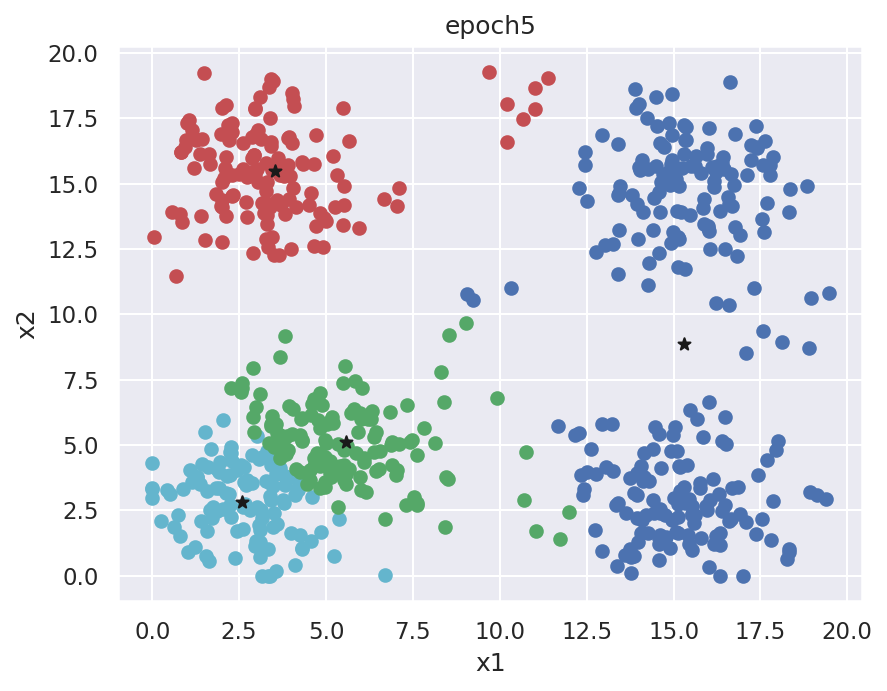

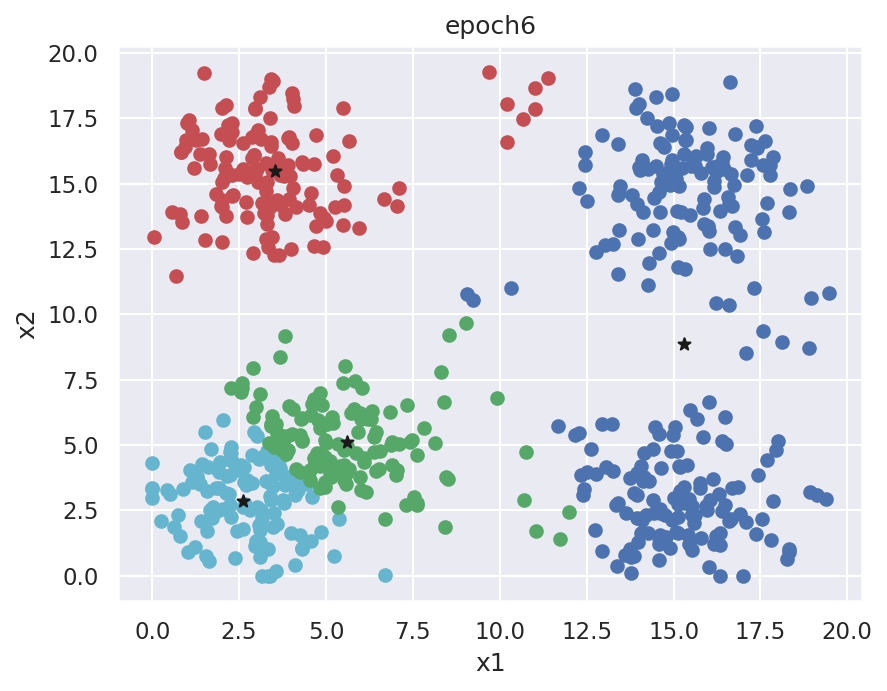

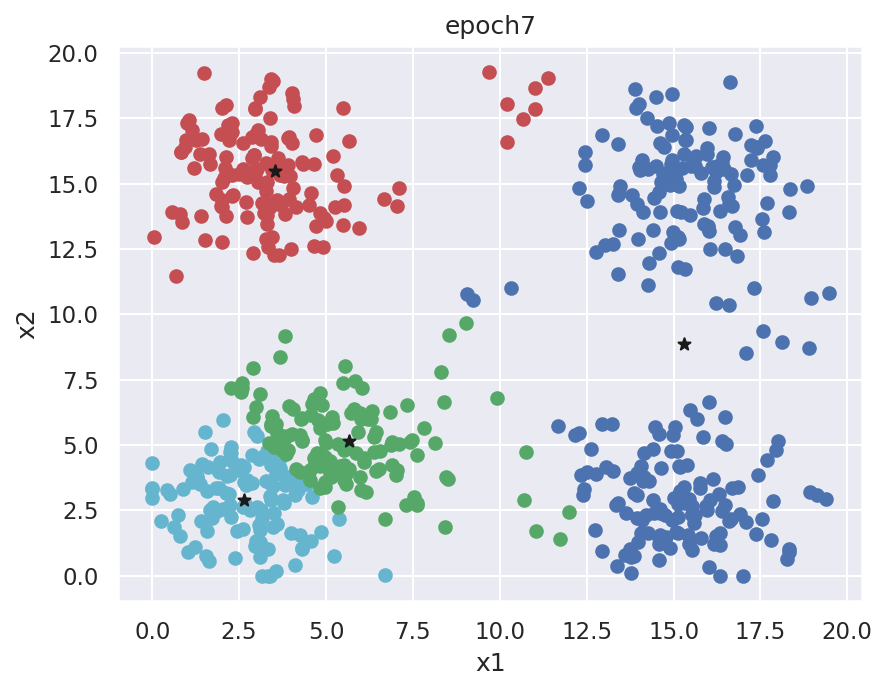

In [28]:
assignment, _ = kmeans(X, k, max_epoch)